In [1]:
# Install required packages:
!pip install pandas matplotlib seaborn numpy

In [2]:
# Step 1: Load the dataset:
import pandas as pd
df = pd.read_csv("loan_data.csv")
print(df.head())
 


   Gender  Age  Income  CreditScore  LoanAmount  Approved
0    Male   35   75000          720      250000         1
1    Male   42   82000          740      300000         1
2  Female   38   68000          690      200000         0
3    Male   29   65000          700      180000         1
4  Female   31   62000          680      175000         0


In [4]:
# Step 2: Examine Dataset Structure
# Display summary information
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Gender       15 non-null     object
 1   Age          15 non-null     int64 
 2   Income       15 non-null     int64 
 3   CreditScore  15 non-null     int64 
 4   LoanAmount   15 non-null     int64 
 5   Approved     15 non-null     int64 
dtypes: int64(5), object(1)
memory usage: 852.0+ bytes
None


In [5]:
# Check statistical summary
print(df.describe())

             Age         Income  CreditScore     LoanAmount   Approved
count  15.000000      15.000000    15.000000      15.000000  15.000000
mean   36.466667   72866.666667   708.000000  235666.666667   0.666667
std     6.906174   13569.222878    41.781746   74423.178673   0.487950
min    27.000000   52000.000000   640.000000  140000.000000   0.000000
25%    30.500000   63500.000000   685.000000  177500.000000   0.000000
50%    36.000000   73000.000000   700.000000  230000.000000   1.000000
75%    41.000000   79500.000000   725.000000  270000.000000   1.000000
max    50.000000  100000.000000   790.000000  400000.000000   1.000000


In [6]:
# Step 3: Analyze Demographic Representation
# Determine how many applicants belong to each gender group
print(df["Gender"].value_counts())

Gender
Male      8
Female    7
Name: count, dtype: int64


In [7]:
# Calculate percentages
gender_pct = (
    df["Gender"]
    .value_counts(normalize=True)
    * 100
)
print(gender_pct)


Gender
Male      53.333333
Female    46.666667
Name: proportion, dtype: float64


In [8]:
# Step 4: Calculate Approval Rates
# Calculate loan approval rates by gender
approval_rates = (
    df.groupby("Gender")["Approved"]
      .mean()
)
print(approval_rates)


Gender
Female    0.285714
Male      1.000000
Name: Approved, dtype: float64


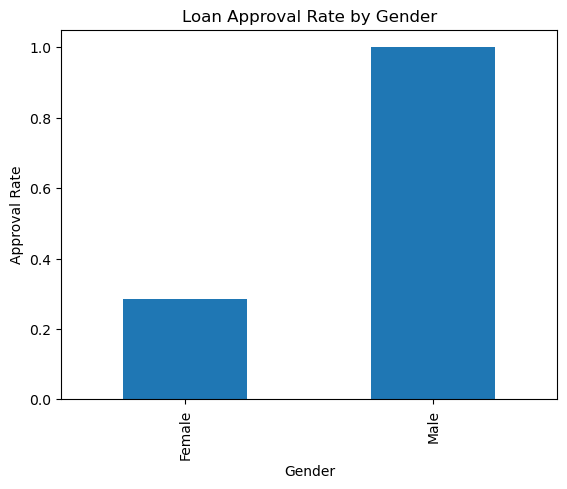

In [9]:
# Step 5: Visualize Approval Rates
# Add visualization code
import matplotlib.pyplot as plt
 
approval_rates.plot(
    kind="bar",
    title="Loan Approval Rate by Gender"
)
 
plt.ylabel("Approval Rate")
plt.show()


In [10]:
# Step 6: Compare Income Levels
# Determine whether income differences explain approval disparities
income_by_gender = (
    df.groupby("Gender")["Income"]
      .mean()
)
 
print(income_by_gender)


Gender
Female    63571.428571
Male      81000.000000
Name: Income, dtype: float64


In [11]:
# Step 7: Analyze Credit Scores
# Calculate average credit scores
credit_scores = (
    df.groupby("Gender")["CreditScore"]
      .mean()
)
 
print(credit_scores)


Gender
Female    675.714286
Male      736.250000
Name: CreditScore, dtype: float64


In [12]:
# Step 9: Optional Bias Metric
# Calculate Disparate Impact Ratio.
female_rate = approval_rates["Female"]
male_rate = approval_rates["Male"]
 
disparate_impact = (
    female_rate / male_rate
)
 
print(
    f"Disparate Impact Ratio: "
    f"{disparate_impact:.2f}"
)


Disparate Impact Ratio: 0.29
